# Exercise 2


## Supervised Learning- Classification Models

---

## Overview

Welcome to this excercise. We are now going to use our new skills to build our supervised learning models that use classification approach.

---


In [1]:
import sys
import os

# Manually set the path relative to the py file's location that you want to import
func_lib_path = os.path.abspath(
    os.path.join(os.getcwd(), "./../")
)  # Add the path to sys.path
sys.path.append(func_lib_path)

# Now you can import func_lib
import func_lib
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler

from sklearn.tree import DecisionTreeClassifier

In [2]:
# Retrieve historical price data.
# - Use the 'createHistPrices()' function from 'func_lib' to get historical price data.
# - Assign the result to the variable 'historical_prices'.

historical_prices = func_lib.create_hist_prices()

# Define the list of momentum periods.
# - Create a list containing different time periods for calculating momentum indicators.
# - Assign this list to the variable 'list_of_momentums'.

list_of_momentums = [1, 5, 15, 20]

# Compute returns based on historical prices and momentum periods.
# - Use the 'computingReturns()' function from 'func_lib' with 'historical_prices' and 'list_of_momentums' as inputs.
# - Assign the result to the variable 'total_returns'.

total_returns = func_lib.compute_returns(historical_prices, list_of_momentums)

# Remove any rows with missing values from the returns data.
# - Use the 'dropna()' method to remove rows with NaN values from 'total_returns'.
# - Apply the change in place to modify the DataFrame directly.

total_returns.dropna(inplace=True)

[*****                 11%                       ]  55 of 501 completed$SNDK: possibly delisted; no price data found  (1d 2000-01-01 -> 2024-05-01) (Yahoo error = "Data doesn't exist for startDate = 946702800, endDate = 1714536000")
[***********           22%                       ]  112 of 501 completed$Q: possibly delisted; no price data found  (1d 2000-01-01 -> 2024-05-01) (Yahoo error = "Data doesn't exist for startDate = 946702800, endDate = 1714536000")
[*********************100%***********************]  501 of 501 completed

2 Failed downloads:
['SNDK', 'Q']: possibly delisted; no price data found  (1d 2000-01-01 -> 2024-05-01) (Yahoo error = "Data doesn't exist for startDate = 946702800, endDate = 1714536000")


In [3]:
# Convert 'F_1_d_returns' to binary values based on whether they are positive or not.
# - Use the 'apply()' function with a lambda expression to create a new column 'F_1_d_returns_Ind'.
# - The lambda expression assigns 1 if the value is greater than 0, otherwise assigns 0.

total_returns["F_1_d_returns_Ind"] = total_returns["F_1_d_returns"].apply(
    lambda x: 1 if x > 0 else 0
)
# Display the updated DataFrame.
total_returns.head()

F_1_d_returns  1_d_returns  5_d_returns  15_d_returns  \
Ticker Date                                                                
A      2000-02-01       0.077465     0.072710     0.048938      0.029918   
       2000-02-02       0.016340     0.077465     0.119854      0.125000   
       2000-02-03      -0.019293     0.016340     0.136073      0.166980   
       2000-02-04       0.042623    -0.019293     0.120294      0.127541   
       2000-02-07      -0.006289     0.042623     0.201133      0.162705   

                   20_d_returns  F_1_d_returns_Ind  
Ticker Date                                         
A      2000-02-01     -0.013889                  1  
       2000-02-02      0.150375                  1  
       2000-02-03      0.246493                  0  
       2000-02-04      0.270833                  1  
       2000-02-07      0.223077                  0

In [4]:
# Determine the split index for 70% of the dates.
# - Extract the unique dates from the index of 'total_returns'.
# - Calculate the split date by indexing into the unique dates to get the date corresponding to 70% of the total length of unique dates.
# - Assign this date to the variable 'split_date' and display it.

unique_dates = total_returns.index.get_level_values("Date").unique()
split_date = unique_dates[int(0.7 * len(unique_dates))]
print(split_date)

2017-01-20 00:00:00


In [5]:
# Create the training set: all data before the split date.
# - Use the 'loc[]' indexer to select rows from 'total_returns' where the date in the index is earlier than 'split_date'.
# - Assign this subset of data to the variable 'train_data'.
train_data = total_returns.loc[
    total_returns.index.get_level_values("Date") < split_date
]
print("Train data, first elements:\n\n", train_data.head(), "\n\n")

# Create the testing set: all data from the split date onwards.
# - Use the 'loc[]' indexer to select rows from 'total_returns' where the date in the index is equal to or later than 'split_date'.
# - Assign this subset of data to the variable 'test_data'.
test_data = total_returns.loc[
    total_returns.index.get_level_values("Date") >= split_date
]
print("Test data, first elements:\n\n", test_data.head(), "\n\n")

Train data, first elements:

                    F_1_d_returns  1_d_returns  5_d_returns  15_d_returns  \
Ticker Date                                                                
A      2000-02-01       0.077465     0.072710     0.048938      0.029918   
       2000-02-02       0.016340     0.077465     0.119854      0.125000   
       2000-02-03      -0.019293     0.016340     0.136073      0.166980   
       2000-02-04       0.042623    -0.019293     0.120294      0.127541   
       2000-02-07      -0.006289     0.042623     0.201133      0.162705   

                   20_d_returns  F_1_d_returns_Ind  
Ticker Date                                         
A      2000-02-01     -0.013889                  1  
       2000-02-02      0.150375                  1  
       2000-02-03      0.246493                  0  
       2000-02-04      0.270833                  1  
       2000-02-07      0.223077                  0   


Test data, first elements:

                    F_1_d_returns  

In [6]:
# Extract the target variable for testing.
# - Select the 'F_1_d_returns' column from the 'test_data' DataFrame.
# - Assign this column to the variable 'total_returns'.
total_returns = test_data["F_1_d_returns"]
total_returns.head()

Ticker  Date      
A       2017-01-20   -0.004830
        2017-01-23   -0.000844
        2017-01-24    0.022387
        2017-01-25   -0.004958
        2017-01-26    0.009965
Name: F_1_d_returns, dtype: float64

In [7]:
# Define the features and target variables.
# - Specify the columns to be used as features ('1_d_returns', '5_d_returns', '15_d_returns', '20_d_returns').
# - Specify the column to be used as the target variable ('F_1_d_returns_Ind').
features = ["1_d_returns", "5_d_returns", "15_d_returns", "20_d_returns"]
target = ["F_1_d_returns_Ind"]

# Split the data into training and testing sets.
# - Extract the feature columns from the training data and testing data.
# - Extract the target column from the training data and testing data.
X_train = train_data[features]
# print(X_train)
X_test = test_data[features]
# print(X_test)
y_train = train_data[target]
# print(y_train)
y_test = test_data[target]
# print(y_test)

In [8]:
# Standardize the features.
# - Create an instance of 'StandardScaler' for scaling the features.
# - Fit the scaler to the training data and transform both the training and testing feature sets.
# - Convert the scaled arrays back to DataFrames with the same index and column names as the original feature sets.
scaler = StandardScaler()

# Scale the training features
X_train_scaled = scaler.fit_transform(X_train)

# Scale the testing features
X_test_scaled = scaler.transform(X_test)

# Convert the scaled arrays back to DataFrames
X_train_scaled = pd.DataFrame(
    X_train_scaled, index=X_train.index, columns=X_train.columns
)
X_test_scaled = pd.DataFrame(X_test_scaled, index=X_test.index, columns=X_test.columns)

In [10]:
# Initialize and train a Decision Tree classifier.
# - Create an instance of the DecisionTreeClassifier class.
# - Fit the model to the scaled training data and the target values.
model = DecisionTreeClassifier()
model.fit(X_train_scaled, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [11]:
# Define the model name.
# - Set a string variable 'model_name' to identify the Decision Tree model.
model_name = "DecTree"

# Make predictions using the trained Decision Tree model.
# - Use the 'predict()' method to generate predictions on the scaled test data.
# - Convert the predictions into a DataFrame and set the index to match the test data.
y_pred = model.predict(X_test_scaled)
y_pred_df = pd.DataFrame(y_pred, index=X_test_scaled.index)

# Rename the column in the predictions DataFrame to reflect the model name.
# - Use 'rename()' to change the column name to 'model_name'.

y_pred_df.rename(columns={0: model_name}, inplace=True)

# Convert the actual target values into a DataFrame.
# - Ensure the DataFrame has the same index as the predictions DataFrame.

y_test_df = pd.DataFrame(y_test)

# Merge the predicted and actual target values with the original DataFrame.
# - Use 'pd.merge()' to combine 'y_pred_df' and 'total_returns' DataFrames based on their indices.

y_test_and_pred = pd.merge(y_pred_df, total_returns, left_index=True, right_index=True)

In [12]:
# Define a trading strategy based on logistic regression predictions.
# - Create a function 'trading_strategy' that takes the predicted value 'y_pred' as input.
# - If the predicted value is greater than 0.5, return 1 (indicating a "Go long" signal).
# - Otherwise, return 0 (indicating no action or "Do nothing").
def trading_strategy(y_pred: float):
    if y_pred > 0:
        return 1  # Go long signal
    else:
        return 0  # Do nothing

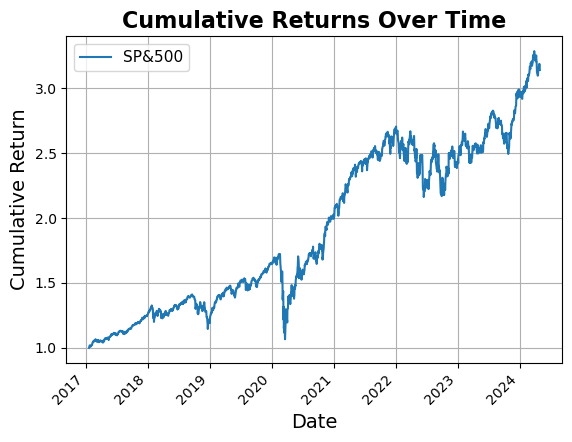

The CAGR is: 16.94%
Sharpe Ratio of Strategy: 0.89


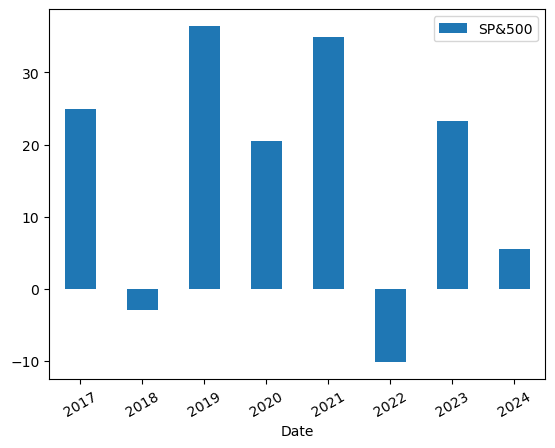

In [13]:
# Compute performance metrics based on the predictions and actual returns.
# - Use the 'func_lib.compute_BM_Perf()' function to calculate cumulative and calendar returns.
# - Pass the DataFrame 'y_test_and_pred' containing the actual and predicted values as an argument.
cum_returns, calendar_returns = func_lib.compute_BM_Perf(y_test_and_pred)

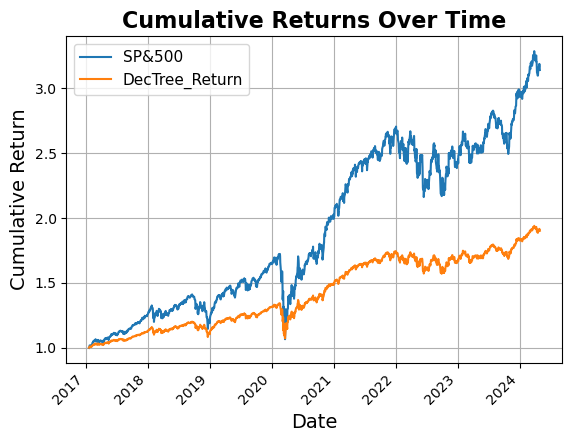

The CAGR is: 9.19%
Sharpe Ratio of Strategy: 0.92


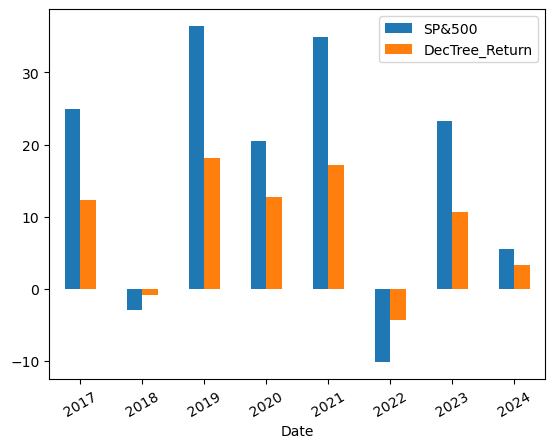

In [14]:
# Compute strategy performance metrics.
# - Use the 'func_lib.compute_strat_perf()' function to calculate the performance of the trading strategy.
# - Pass the following arguments:
#   - 'y_test_and_pred': The DataFrame containing actual and predicted values.
#   - 'cum_returns': Cumulative returns calculated previously.
#   - 'calendar_returns': Calendar returns calculated previously.
#   - 'trading_strategy': The function defining the trading strategy based on predictions.
#   - 'model_name': The name of the model to include in the performance evaluation.
cum_returns, calendar_returns = func_lib.compute_strat_perf(
    y_test_and_pred, cum_returns, calendar_returns, trading_strategy, model_name
)